# Kelompok H EDA

Anggota :
1. Muhammad Jauhar Hakim     2006463982
2. Galih Nur Kantaatmaja 2006571141
3. Irba Alifa Taqiyya  2006571223
4. Nisrina Anbar Fadhilah   2006571072
5. Peksyaji    2006522322

In [ ]:
import warnings; warnings.simplefilter('ignore')
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import matplotlib.cm as cm
from collections import Counter
plt.style.use('bmh'); sns.set()

# Tugas 1

In [ ]:
try:
    # Running Locally 
    price = pd.read_csv('data/price.csv')
except:
    # Running in Google Colab
    !mkdir data
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/price.csv
    price = pd.read_csv('data/price.csv')

--2021-04-14 02:36:07--  https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/price.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53592 (52K) [text/plain]
Saving to: ‘data/price.csv’

price.csv           100%[===================>]  52.34K  --.-KB/s    in 0.006s  

2021-04-14 02:36:07 (8.90 MB/s) - ‘data/price.csv’ saved [53592/53592]



In [ ]:
price.drop("Observation", axis=1, inplace=True) 
price.drop_duplicates(inplace=True) # menghilangkan data duplikat
price['Parking'] = price['Parking'].astype('category') 
price['City_Category'] = price['City_Category'].astype('category')
price2 = price[np.abs(price.House_Price - price.House_Price.mean())<=(2*price.House_Price.std())] 
price2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 931 entries, 0 to 931
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Dist_Taxi      918 non-null    float64 
 1   Dist_Market    918 non-null    float64 
 2   Dist_Hospital  930 non-null    float64 
 3   Carpet         923 non-null    float64 
 4   Builtup        916 non-null    float64 
 5   Parking        931 non-null    category
 6   City_Category  931 non-null    category
 7   Rainfall       931 non-null    int64   
 8   House_Price    931 non-null    int64   
dtypes: category(2), float64(5), int64(2)
memory usage: 60.3 KB


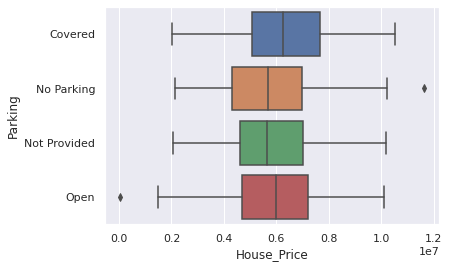

In [ ]:
p = sns.boxplot(x="House_Price", y="Parking", data=price2)

In [ ]:
Q1 = price2['House_Price'].quantile(0.25)
Q3 = price2['House_Price'].quantile(0.75)
IQR = Q3-Q1  #IQR adalah interquartile range
print('Q1={}, Q3={}, IQR={}'.format(Q1, Q3, IQR))

Q1=4658000.0, Q3=7180500.0, IQR=2522500.0


In [ ]:
outliers_atas = (price2['House_Price']>(Q3+1.5*IQR))
price2.loc[outliers_atas].head()

,Dist_Taxi,Dist_Market,Dist_Hospital,Carpet,Builtup,Parking,City_Category,Rainfall,House_Price
678,7288.0,9560.0,12531.0,1989.0,2414.0,No Parking,CAT A,860,11632000


In [ ]:
outliers_atas

0      False
1      False
2      False
3      False
4      False
       ...  
927    False
928    False
929    False
930    False
931    False
Name: House_Price, Length: 931, dtype: bool

In [ ]:
price2.drop(labels=[678],axis=0,inplace=True) #mengeluarkan outlier


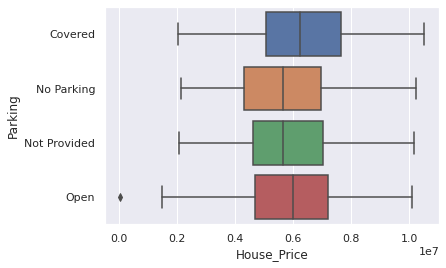

In [ ]:
p1 = sns.boxplot(x="House_Price", y="Parking", data=price2) #menampilkan boxplot tanpa outlier atas

# Tugas 2

In [ ]:
import warnings; warnings.simplefilter('ignore')
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import matplotlib.cm as cm
from collections import Counter
plt.style.use('bmh'); sns.set()

In [ ]:
# Importing CSV data  https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html
try:
    # Running Locally 
    price = pd.read_csv('data/price.csv')
except:
    # Running in Google Colab
    !mkdir data
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/price.csv
    price = pd.read_csv('data/price.csv')

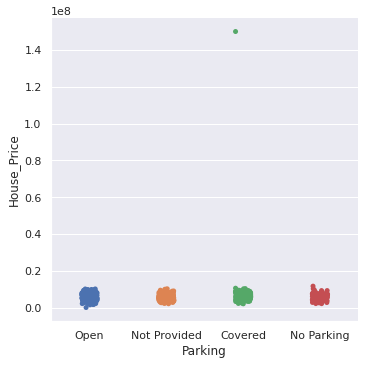

In [ ]:
p= sns.catplot(x="Parking", y="House_Price", data=price)
df = np.abs(price.House_Price - price.House_Price.mean())<=(2*price.House_Price.std())
# mu-2s<x<mu+2s
#print(df.shape)
df.head()
price2 = price[df] # Data tanpa outliers
#print(price2.shape, price.shape)

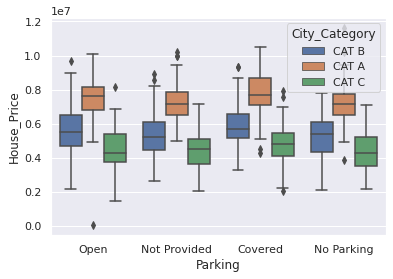

In [ ]:
p= sns.boxplot(x="Parking", y="House_Price", hue="City_Category", data=price2)

In [ ]:
Q1= price['House_Price'].quantile(0.25)                           #Mengecek Outlier bawah
Q3= price['House_Price'].quantile(0.75)
IQR = Q3 - Q1
print('Q1={}, Q3={}, IQR = {}'.format(Q1, Q3, IQR))

outliers_bawah = (price['House_Price'] < (Q1 - 1.5 *IQR)) 
price.loc[outliers_bawah].head()  

Q1=4661000.0, Q3=7187250.0, IQR = 2526250.0


,Observation,Dist_Taxi,Dist_Market,Dist_Hospital,Carpet,Builtup,Parking,City_Category,Rainfall,House_Price
811,812,NaN,NaN,NaN,NaN,NaN,Open,CAT A,440,30000


In [ ]:
price2.drop(labels=[811],axis=0,inplace=True)     # Menghapus Outlier bawah pada baris '811'

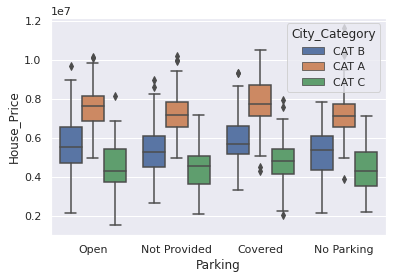

In [ ]:
p= sns.boxplot(x="Parking", y="House_Price", hue="City_Category", data=price2)

Outlier bawah dapat dikeluarkan dari boxplot diatas dengan menggunakan price2.drop()function.

# Tugas 3

Sebuah dataset dari suatu Restaurant memuat variabel-variabel berikut:
*	total_bill: Total bill (cost of the meal), including tax, in US dollars
*	tip: Tip (gratuity) in US dollars
*	sex: Sex of person paying for the meal (0=male, 1=female)
*	smoker: Smoker in party? (0=No, 1=Yes)
*	day: 3=Thur, 4=Fri, 5=Sat, 6=Sun
*	time: 0=Day, 1=Night
*	size: Size of the party

https://www.kaggle.com/ranjeetjain3/seaborn-tips-dataset

In [ ]:
# Loading Contoh Data studi kasus pertama di atas
tips = sns.load_dataset('tips') # Loading dari SeaBorn library's dataset
# Ukuran Data
N, P = tips.shape
print('baris = ', N, ', Kolom = ', P)

tips.head()

baris =  244 , Kolom =  7


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


**Nomor 1**

Adakah tipe variabel yang kurang tepat di data tersebut?

In [ ]:
tips = sns.load_dataset('tips')     # Loading dari SeaBorn Library's dataset
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.3 KB


Pada data tersebut, terdapat tipe variabel yang kurang tepat yakni tipe category

**Nomor 2**

Apakah data numeriknya cenderung berdistribusi normal?

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f8cebdb1890>,
      dtype=object)

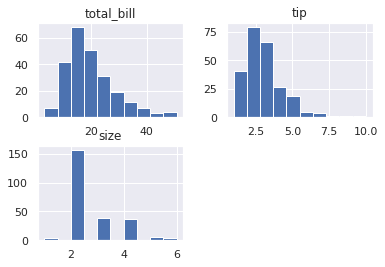

In [ ]:
tips = sns.load_dataset('tips')       # Loading dari SeaBorn Library's dataset
tips.hist()

Dari visualisasi histogram diatas dapat dilihat data numeriknya yakni data total bill, data tip, dan data size cenderung tidak berdistribusi normal. Hal ini disebabkan karena data mean, modus, dan mediannya tidak berada pada titik yang sama sehingga kurvanya menjadi tidak simetris

**Nomor 3**


Apakah ada outlier, noise, missing values, dan-atau duplikasi data?

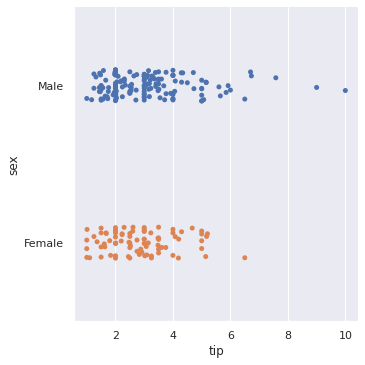

In [ ]:
#mengecek outlier
p = sns.catplot(x="tip", y="sex", data=tips)

In [ ]:
#mengecek duplikasi data
print(tips.shape)
tips.duplicated().sum()

(244, 7)


1



*   Terdapat outlier data, dimana pelanggan pria memberikan tip lebih dari 8 USD dan pelanggan wanita memberikan tip lebih dari 6 USD
*   Terdapat duplikasi data pada baris ke-244 kolom ke-7



**Nomor 4**

Apakah pelanggan pria dan wanita cenderung proporsional (balance)?

Male      157
Female     87
Name: sex, dtype: int64


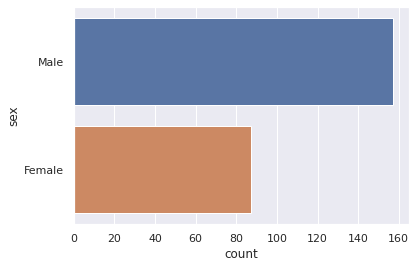

In [ ]:
print(tips['sex'].value_counts()) #Jumlah laki-laki dan perempuan dalam bentuk series
sns.countplot(y="sex", data=tips) #Memvisualisasikan jumlah laki-laki dan perempuan dalam bar chart

Jawab No 4: Pelanggan pria dan juga watina tidaklah proporsional karena bisa dilihat dari gambar di atas bahwa pelanggan pria hampir mendekati 2x lebih banyak daripada pelanggan perempuan dengan selisihnya yaitu 157-87= 70

**Nomor 5**

Dari data yang ada apakah Pria atau wanita ada kecenderungan memberi tips lebih besar?

In [ ]:
tips22= tips.set_index('sex') #Membuat dataframe baru dengan indexnya berdasarkan 'sex' yaitu antara Male atau Female
tips22.head()

,total_bill,tip,smoker,day,time,size
sex,,,,,,
Female,16.99,1.01,No,Sun,Dinner,2
Male,10.34,1.66,No,Sun,Dinner,3
Male,21.01,3.50,No,Sun,Dinner,3
Male,23.68,3.31,No,Sun,Dinner,2
Female,24.59,3.61,No,Sun,Dinner,4


In [ ]:
#Memisahkan dataframe berdasarkan index
mm22=tips22.loc[['Male']] #mm22 merupakan dataframe dengan berindex semuanya Male
ff22=tips22.loc[['Female']] #ff22 merupakan dataframe dengan berindex semuanya Female

In [ ]:
print(mm22)
print(ff22)

      total_bill   tip smoker  day    time  size
sex                                             
Male       10.34  1.66     No  Sun  Dinner     3
Male       21.01  3.50     No  Sun  Dinner     3
Male       23.68  3.31     No  Sun  Dinner     2
Male       25.29  4.71     No  Sun  Dinner     4
Male        8.77  2.00     No  Sun  Dinner     2
...          ...   ...    ...  ...     ...   ...
Male       12.60  1.00    Yes  Sat  Dinner     2
Male       32.83  1.17    Yes  Sat  Dinner     2
Male       29.03  5.92     No  Sat  Dinner     3
Male       22.67  2.00    Yes  Sat  Dinner     2
Male       17.82  1.75     No  Sat  Dinner     2

[157 rows x 6 columns]
        total_bill   tip smoker   day    time  size
sex                                                
Female       16.99  1.01     No   Sun  Dinner     2
Female       24.59  3.61     No   Sun  Dinner     4
Female       35.26  5.00     No   Sun  Dinner     4
Female       14.83  3.02     No   Sun  Dinner     2
Female       10.33  1.67   

In [ ]:
#Semua Statistika Deskriptif dari mm22
mm22.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
total_bill,157.0,20.744076,9.246469,7.25,14.0,18.35,24.71,50.81
tip,157.0,3.089618,1.489102,1.00,2.0,3.00,3.76,10.00
size,157.0,2.630573,0.955997,1.00,2.0,2.00,3.00,6.00


In [ ]:
#Semua Statistika Deskriptif dari ff22
ff22.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
total_bill,87.0,18.056897,8.009209,3.07,12.75,16.40,21.52,44.3
tip,87.0,2.833448,1.159495,1.00,2.00,2.75,3.50,6.5
size,87.0,2.459770,0.937644,1.00,2.00,2.00,3.00,6.0


<img alt="" src="https://i.imgur.com/QXZlf6P.png"/>

Jawab No 5 : Bisa dilihat dari grafik diatas, dilihat dari mean dan median, tip yang diberikan oleh pelanggan pria lebih besar dibandingkan dari pelanggan wanita

**Nomor 6**

Dari data yang ada apakah ada kecenderungan tips lebih besar di hari-hari tertentu?

In [ ]:
tips["day"].unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Sun', 'Sat', 'Thur', 'Fri']

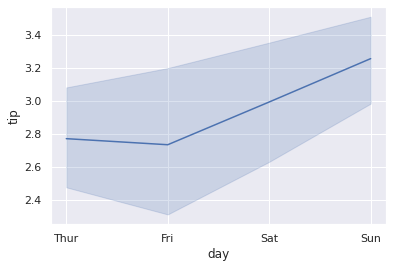

In [ ]:
plot = sns.lineplot(x="day", y="tip", data=tips)

Jawab No 6 : Ya ada kecenderungan tip lebih besar di hari minggu. Urutan Pertama tip terbesar ialah pada hari minggu lalu diikuti oleh hari Sabtu lalu hari Kamis dan paling sedikit adalah hari Jumat.

**Nomor 7**

Dari data yang ada apakah customer perokok cenderung memberi tips lebih besar?

In [ ]:
tips7= tips.set_index('smoker') #Membuat dataframe baru dengan indexnya berdasarkan 'smoker' yaitu antara Yes atau No
tips7.head()

,total_bill,tip,sex,day,time,size
smoker,,,,,,
No,16.99,1.01,Female,Sun,Dinner,2
No,10.34,1.66,Male,Sun,Dinner,3
No,21.01,3.50,Male,Sun,Dinner,3
No,23.68,3.31,Male,Sun,Dinner,2
No,24.59,3.61,Female,Sun,Dinner,4


In [ ]:
#Memisahkan dataframe berdasarkan index
merokok = tips7.loc[['Yes']] #merokok merupakan dataframe dengan berindex semuanya Yes
tdk_merokok = tips7.loc[['No']] #tdk_merokok merupakan dataframe dengan berindex semuanya No

In [ ]:
print(merokok)
print(tdk_merokok)

        total_bill   tip     sex  day    time  size
smoker                                             
Yes          38.01  3.00    Male  Sat  Dinner     4
Yes          11.24  1.76    Male  Sat  Dinner     2
Yes          20.29  3.21    Male  Sat  Dinner     2
Yes          13.81  2.00    Male  Sat  Dinner     2
Yes          11.02  1.98    Male  Sat  Dinner     2
...            ...   ...     ...  ...     ...   ...
Yes          15.53  3.00    Male  Sat  Dinner     2
Yes          12.60  1.00    Male  Sat  Dinner     2
Yes          32.83  1.17    Male  Sat  Dinner     2
Yes          27.18  2.00  Female  Sat  Dinner     2
Yes          22.67  2.00    Male  Sat  Dinner     2

[93 rows x 6 columns]
        total_bill   tip     sex   day    time  size
smoker                                              
No           16.99  1.01  Female   Sun  Dinner     2
No           10.34  1.66    Male   Sun  Dinner     3
No           21.01  3.50    Male   Sun  Dinner     3
No           23.68  3.31    Male   S

In [ ]:
#Semua Statistika Deskriptif dari merokok
merokok.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
total_bill,93.0,20.756344,9.832154,3.07,13.42,17.92,26.86,50.81
tip,93.0,3.008710,1.401468,1.00,2.00,3.00,3.68,10.00
size,93.0,2.408602,0.810751,1.00,2.00,2.00,3.00,5.00


In [ ]:
#Semua Statistika Deskriptif dari tdk_merokok
tdk_merokok.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
total_bill,151.0,19.188278,8.255582,7.25,13.325,17.59,22.755,48.33
tip,151.0,2.991854,1.377190,1.00,2.000,2.74,3.505,9.00
size,151.0,2.668874,1.017984,1.00,2.000,2.00,3.000,6.00


Jawaban nomor 7:
Dari tabel di atas, dapat diketahui bahwa pelanggan yang merokok cenderung membayar tip lebih besar dari pelanggan yang merokok

**Nomor 8**

Apakah pola di nomor 5 dan 7 dipengaruhi hari?

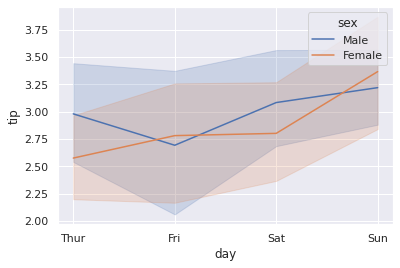

In [ ]:
plot_sex = sns.lineplot(x="day", y="tip", hue='sex', data=tips)

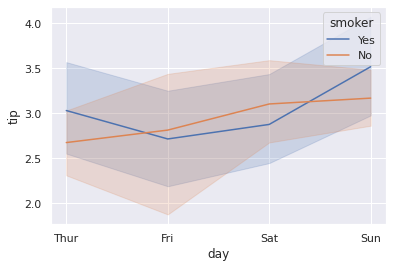

In [ ]:
plot_rokok = sns.lineplot(x="day", y="tip", hue='smoker', data=tips)

Jawaban nomor 8: Berdasarkan kedua grafik di atas, dapat ditarik kesimpulan bahwa soal nomor 5 dan nomor 7 diperngaruhi hari

**Nomor 9**

Pola apalagi yang dapat anda temukan? 

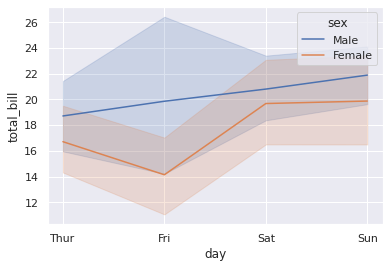

In [ ]:
plot_bill91 = sns.lineplot(x='day',y='total_bill',hue='sex',data=tips)

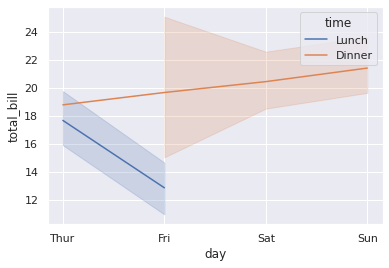

In [ ]:
plot_bill92 = sns.lineplot(x='day',y='total_bill',hue='time',data=tips)

Berdasarkan 2 grafik di atas, dapat disarankan kepada pengelola restauran untuk:

1. Pada hari sabtu dan minggu mengurangi pekerja yang berangkat siang karena pengunjung yang makan siang sedikit
2. Pada hari sabtu dan minggu memutar lagu yang santai dan bertema perasaan. karena jumlah pengunjung pria dan wanita mirip sehingga dapat diasumsikan mereka datang berpasangan

**Nomor 10**

Dari hasil EDA yang telah dibuat, dapat disarankan kepada pemilik restauran untuk:
1. Membuat suasana restauran yang lebih nyaman untuk laki-laki karena pengunjung yang datang cenderung laki-laki.
2. Pada hari sabtu dan minggu mengurangi pekerja yang berangkat siang karena pengunjung yang makan siang sedikit
3. Pada hari sabtu dan minggu memutar lagu yang santai dan bertema perasaan. karena jumlah pengunjung pria dan wanita mirip sehingga dapat diasumsikan mereka datang berpasangan
4. Membuat suasana yang nyaman untuk perempuan pada hari Jumat dan Minggu, karena pada hari itu pengunjung yang datang kebanyakan perempuan.
5. Menyediakan fasilitas yang lebih baik untuk perokok seperti ruang terbuka yang nyaman dan juga asbak.
6. Menambahkan meja dan kursi lebih banyak pada ruang khusus perokok di hari Kamis dan Sabtu

**Nomor 11**

Skill/Kompetensi apa yang terasa sangat diperlukan dari latihan ini?

Skill berpikir kritis adalah kompetensi yang sangat diperlukan dalam tugas ini.
Berpikir kritis dapat memicu kita berpikir secara logis serta memiliki alasan yang jelas.
Oleh karena itu, kemampuan berpikir kritis sangat diperlukan dalam pemecahan masalah sehingga
hasil dari pemikiran kritis itu dapat dipertanggungjawabkan secara implisit.
Yang kedua, teamwork merupakan skill yang mampu membuat beban pekerjaan kita menjadi lebih ringan
untuk dikerjakan. Hal ini karena di dalam anggota tim dapat saling melengkapi kekurangan 
dan kelebihan satu sama lain. Dengan teamwork, kita dapat melakukan kolaborasi sehingga pekerjaan
lebih efisien dan menghasilkan ide-ide cemerlang.